In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

mlp_term_3_2025_kaggle_assignment_2_path = kagglehub.competition_download('mlp-term-3-2025-kaggle-assignment-2')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mlp-term-3-2025-kaggle-assignment-2/sample_submission.csv
/kaggle/input/mlp-term-3-2025-kaggle-assignment-2/train.csv
/kaggle/input/mlp-term-3-2025-kaggle-assignment-2/test.csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [ ]:
train_df = pd.read_csv('/kaggle/input/mlp-term-3-2025-kaggle-assignment-2/train.csv')
test_df = pd.read_csv('/kaggle/input/mlp-term-3-2025-kaggle-assignment-2/test.csv')
sample_submission = pd.read_csv('/kaggle/input/mlp-term-3-2025-kaggle-assignment-2/sample_submission.csv')

In [ ]:
train_df.head()

,id,adults,children,weekends,weekdays,meal_type,room_type,arrival,lead_time,segment,repeat,price,requests,booking_status
0,0,2,0,0,1,Not Selected,Room_Type 1,2018-05-21,54.0,Online,0,116.10,0,1
1,1,1,0,3,6,Not Selected,Room_Type 1,2018-11-12,12.0,Online,0,71.87,1,1
2,2,2,0,0,2,Meal Plan 1,Room_Type 2,2018-01-06,34.0,Online,0,71.55,1,0
3,3,1,0,2,1,Meal Plan 1,Room_Type 1,2018-02-14,4.0,Corporate,1,66.00,0,0
4,4,2,0,2,3,Meal Plan 1,Room_Type 1,2018-07-08,155.0,Offline,0,72.25,0,0


# 1. Identify data types of different columns

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29500 entries, 0 to 29499
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              29500 non-null  int64  
 1   adults          29500 non-null  int64  
 2   children        29500 non-null  int64  
 3   weekends        29500 non-null  int64  
 4   weekdays        29500 non-null  int64  
 5   meal_type       29500 non-null  object 
 6   room_type       28659 non-null  object 
 7   arrival         29500 non-null  object 
 8   lead_time       27805 non-null  float64
 9   segment         29500 non-null  object 
 10  repeat          29500 non-null  int64  
 11  price           27917 non-null  float64
 12  requests        29500 non-null  int64  
 13  booking_status  29500 non-null  int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 3.2+ MB


| Datatypes       | No of Features |
|-----------------|---------------|
| Int64           | 08            |
| Object          | 04            |
| Float64    | 02           |


# 2. Present descriptive statistics of numerical columns

In [ ]:
train_df.drop('id',axis=1).describe()

,adults,children,weekends,weekdays,lead_time,repeat,price,requests,booking_status
count,29500.000000,29500.000000,29500.000000,29500.000000,27805.000000,29500.000000,27917.000000,29500.000000,29500.000000
mean,1.843559,0.106576,0.808136,2.202237,85.405431,0.026000,103.483304,0.619661,0.326441
std,0.518711,0.405517,0.868835,1.404200,85.939750,0.159138,35.120922,0.785919,0.468919
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,17.000000,0.000000,80.500000,0.000000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,58.000000,0.000000,99.880000,0.000000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,127.000000,0.000000,120.180000,1.000000,1.000000
max,4.000000,10.000000,6.000000,17.000000,443.000000,1.000000,375.500000,5.000000,1.000000


In [ ]:
test_df.drop('id',axis=1).describe()

,adults,children,weekends,weekdays,lead_time,repeat,price,requests
count,7000.000000,7000.000000,7000.000000,7000.000000,6588.000000,7000.000000,6594.000000,7000.000000
mean,1.849857,0.101286,0.821000,2.210857,84.540984,0.024429,103.203453,0.619143
std,0.518441,0.392309,0.877617,1.435909,85.898111,0.154387,34.853798,0.787696
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,16.000000,0.000000,80.085000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,56.000000,0.000000,99.000000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,124.000000,0.000000,120.000000,1.000000
max,4.000000,3.000000,7.000000,17.000000,443.000000,1.000000,540.000000,4.000000


# 3. Identify and handle the missing values

In [ ]:
train_ids = train_df["id"]
test_ids = test_df["id"]
train_df = train_df.drop("id", axis=1)
test_df = test_df.drop("id", axis=1)

# Convert arrival date
for df in [train_df, test_df]:
    df["arrival"] = pd.to_datetime(df["arrival"], errors="coerce")
    df["arrival_year"] = df["arrival"].dt.year
    df["arrival_month"] = df["arrival"].dt.month
    df["arrival_day"] = df["arrival"].dt.day
    df.drop("arrival", axis=1, inplace=True)

In [ ]:
test_df.isnull().sum()

adults              0
children            0
weekends            0
weekdays            0
meal_type           0
room_type        1660
lead_time         412
segment             0
repeat              0
price             406
requests            0
arrival_year        8
arrival_month       8
arrival_day         8
dtype: int64

In [ ]:
train_df.isnull().sum()

adults               0
children             0
weekends             0
weekdays             0
meal_type            0
room_type          841
lead_time         1695
segment              0
repeat               0
price             1583
requests             0
booking_status       0
arrival_year        29
arrival_month       29
arrival_day         29
dtype: int64

In [ ]:
cat_cols = ["meal_type", "room_type", "segment"]
num_cols = ['adults', 'children', 'weekends', 'weekdays',
            'lead_time', 'price', 'requests',
            'arrival_year', 'arrival_month', 'arrival_day']

# Fill missing numerical with median
for col in num_cols:
    train_df[col] = train_df[col].fillna(train_df[col].median())
    test_df[col] = test_df[col].fillna(train_df[col].median())

# Fill missing categorical with mode
for col in cat_cols:
    train_df[col] = train_df[col].fillna(train_df[col].mode()[0])
    test_df[col] = test_df[col].fillna(train_df[col].mode()[0])

# 4. Identify and handle duplicates

In [ ]:
# Duplicates in training data
print("\nChecking for duplicate rows in training data...")
duplicate_count = train_df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    train_df = train_df.drop_duplicates().reset_index(drop=True)
    print(f"Duplicates removed. New train shape: {train_df.shape}")
else:
    print("No duplicates found.")

# Duplicates in test data
print("\nChecking for duplicate rows in Test data...")
duplicate_count = train_df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    train_df = train_df.drop_duplicates().reset_index(drop=True)
    print(f"Duplicates removed. New test shape: {train_df.shape}")
else:
    print("No duplicates found.")


Checking for duplicate rows in training data...
Duplicate rows found: 7151
Duplicates removed. New train shape: (22349, 15)

Checking for duplicate rows in Test data...
Duplicate rows found: 0
No duplicates found.


# 5. Identify and handle outliers

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
def clip_outliers(df, columns):
    summary_data = []
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # Count outliers
        outliers = df[(df[col] < lower) | (df[col] > upper)][col]
        count = outliers.count()
        pct = round((count / len(df)) * 100, 2)

        summary_data.append({
        'Column': col,
        'Outlier Count': count,
        'Outlier %': f"{pct:.2f}%",
        'lower_bound': f"{lower:.2f}",
        'Upper_bound': f"{upper:.2f}"
        })
        summary_df = pd.DataFrame(summary_data)
        # Clip
        df[col] = df[col].clip(lower, upper)

    return df, summary_df

train_df, train_report = clip_outliers(train_df, num_cols)
test_df, test_report = clip_outliers(test_df, num_cols)

# To see the results:
test_report

,Column,Outlier Count,Outlier %,lower_bound,Upper_bound
0,adults,1967,28.10%,2.00,2.00
1,children,496,7.09%,0.00,0.00
2,weekends,7,0.10%,-3.00,5.00
3,weekdays,74,1.06%,-2.00,6.00
4,lead_time,339,4.84%,-132.00,268.00
5,price,289,4.13%,22.73,178.12
6,requests,149,2.13%,-1.50,2.50
7,arrival_year,1252,17.89%,2018.00,2018.00
8,arrival_month,0,0.00%,-2.50,17.50
9,arrival_day,0,0.00%,-14.50,45.50


In [ ]:
train_report

,Column,Outlier Count,Outlier %,lower_bound,Upper_bound
0,adults,6149,27.51%,2.00,2.00
1,children,2138,9.57%,0.00,0.00
2,weekends,14,0.06%,-3.00,5.00
3,weekdays,235,1.05%,-2.00,6.00
4,lead_time,902,4.04%,-110.50,221.50
5,price,1018,4.56%,18.45,187.65
6,requests,568,2.54%,-1.50,2.50
7,arrival_year,3431,15.35%,2018.00,2018.00
8,arrival_month,0,0.00%,-2.50,17.50
9,arrival_day,0,0.00%,-14.50,45.50


# 6. Present at least three visualizations and provide insights for the same

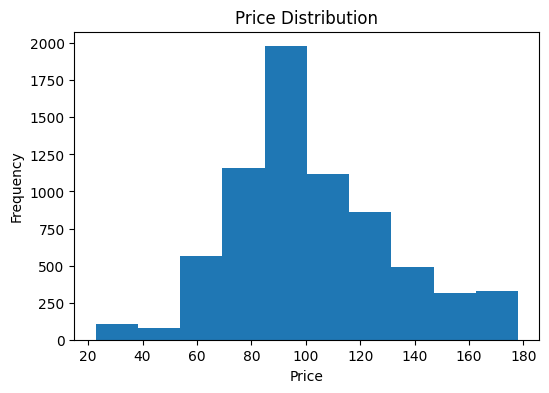

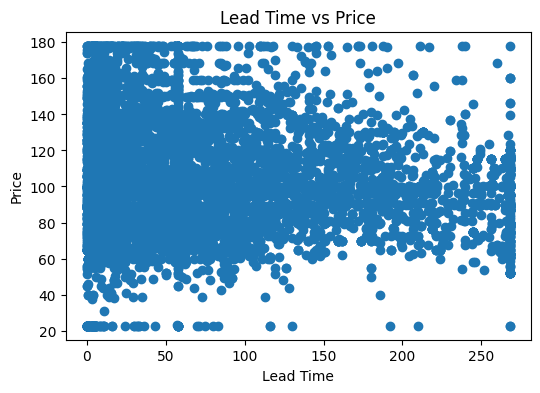

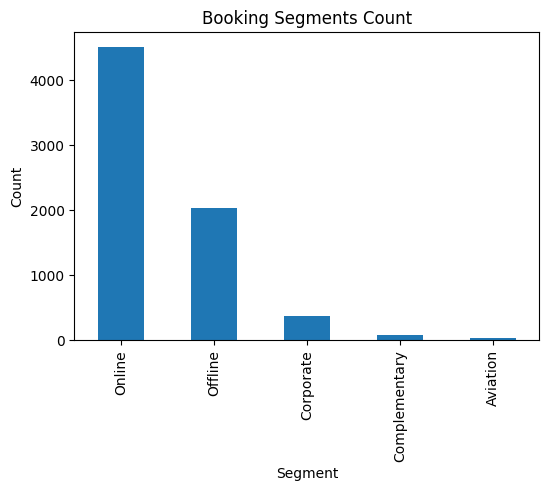

In [ ]:
# Plot 1: Histogram of price
plt.figure(figsize=(6,4))
plt.hist(df["price"])
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# Plot 2: Scatter plot lead_time vs price
plt.figure(figsize=(6,4))
plt.scatter(df["lead_time"], df["price"])
plt.title("Lead Time vs Price")
plt.xlabel("Lead Time")
plt.ylabel("Price")
plt.show()

# Plot 3: Bar chart of booking segments
plt.figure(figsize=(6,4))
df["segment"].value_counts().plot(kind="bar")
plt.title("Booking Segments Count")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.show()

# 7. Scale Numerical features and Encode Categorical features

In [ ]:
X = train_df.drop("booking_status", axis=1)
y = train_df["booking_status"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# 8. Model Building (at least 7)

In [ ]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=500),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

results = {}

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_val)
    acc = accuracy_score(y_val, pred)
    results[name] = acc
    print(f"{name}: {acc:.4f}")
print('done')

LogisticRegression: 0.8016
DecisionTree: 0.7964
RandomForest: 0.8512
GradientBoosting: 0.8376
KNN: 0.8022
SVM: 0.8251
XGBoost: 0.8423
done


# 9. Hyperparameter Tuning on any 3 of the models

In [ ]:
tuned_results = {}

# Random Forest Tuning
rf_params = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [8, 12]
}

rf_grid = GridSearchCV(
    Pipeline([("preprocess", preprocessor),
              ("model", RandomForestClassifier())]),
    rf_params,
    cv=3
)
rf_grid.fit(X_train, y_train)
tuned_results["RandomForest_Tuned"] = accuracy_score(y_val, rf_grid.predict(X_val))

# SVM Tuning
svm_params = {
    "model__C": [1, 5],
    "model__kernel": ["rbf", "linear"]
}

svm_grid = GridSearchCV(
    Pipeline([("preprocess", preprocessor),
              ("model", SVC())]),
    svm_params,
    cv=3
)
svm_grid.fit(X_train, y_train)
tuned_results["SVM_Tuned"] = accuracy_score(y_val, svm_grid.predict(X_val))

# XGBoost Tuning
xgb_params = {
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [4, 6]
}

xgb_grid = GridSearchCV(
    Pipeline([("preprocess", preprocessor),
              ("model", XGBClassifier(eval_metric='logloss'))]),
    xgb_params,
    cv=3
)
xgb_grid.fit(X_train, y_train)
tuned_results["XGB_Tuned"] = accuracy_score(y_val, xgb_grid.predict(X_val))

print("\nTuned Model Results:")
for k, v in tuned_results.items():
    print(k, ":", round(v, 4))

print('done')


Tuned Model Results:
RandomForest_Tuned : 0.8441
SVM_Tuned : 0.83
XGB_Tuned : 0.8407
done


# 10. Comparison of model performances

In [ ]:
best_model_name = max({**results, **tuned_results}, key=lambda x: ({**results, **tuned_results})[x])
print("\nBest Model:", best_model_name)

best_model = {
    "RandomForest_Tuned": rf_grid,
    "SVM_Tuned": svm_grid,
    "XGB_Tuned": xgb_grid
}.get(best_model_name, None)

if best_model is None:
    best_model = Pipeline([("preprocess", preprocessor),
                           ("model", models[best_model_name])])
    best_model.fit(X, y)
else:
    best_model.fit(X, y)

test_pred = best_model.predict(test_df)


Best Model: RandomForest


In [ ]:
submission = pd.DataFrame({
    "id": test_ids,
    "booking_status": test_pred
})

submission.to_csv("submission.csv", index=False)
print("submission.csv saved")

submission.csv saved


In [ ]:
# import pandas as pd
# from catboost import CatBoostClassifier
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score

# # ------------------------------
# # 1. Basic Preprocessing
# # ------------------------------

# train_ids = train_df['id']
# test_ids = test_df['id']

# train_df = train_df.drop('id', axis=1)
# test_df = test_df.drop('id', axis=1)

# # Convert arrival date
# for df in [train_df, test_df]:
#     df['arrival'] = pd.to_datetime(df['arrival'], errors='coerce')
#     df['arrival_year'] = df['arrival'].dt.year
#     df['arrival_month'] = df['arrival'].dt.month
#     df['arrival_day'] = df['arrival'].dt.day
#     df.drop('arrival', axis=1, inplace=True)

# # ------------------------------
# # 2. Categorical handling (fix NaN issue)
# # ------------------------------

# cat_cols = ['meal_type', 'room_type', 'segment']

# for col in cat_cols:
#     train_df[col] = train_df[col].astype(str).fillna("Unknown")
#     test_df[col] = test_df[col].astype(str).fillna("Unknown")

# # ------------------------------
# # 3. Target split
# # ------------------------------
# X = train_df.drop('booking_status', axis=1)
# y = train_df['booking_status']

# # ------------------------------
# # 4. Train/Val Split
# # ------------------------------
# X_train, X_val, y_train, y_val = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# # ------------------------------
# # 5. CatBoost Classifier
# # ------------------------------
# model = CatBoostClassifier(
#     depth=8,
#     learning_rate=0.05,
#     iterations=1200,
#     eval_metric='Accuracy',
#     random_seed=42,
#     verbose=100
# )

# model.fit(
#     X_train, y_train,
#     cat_features=cat_cols,
#     eval_set=(X_val, y_val)
# )

# # ------------------------------
# # 6. Validation Score
# # ------------------------------
# val_pred = model.predict(X_val)
# print("Validation Accuracy:", accuracy_score(y_val, val_pred))

# # ------------------------------
# # 7. Train on full data + Predict
# # ------------------------------
# model.fit(X, y, cat_features=cat_cols)
# predictions = model.predict(test_df)

# # ------------------------------
# # 8. Submission
# # ------------------------------
# submission = pd.DataFrame({
#     'id': test_ids,
#     'booking_status': predictions
# })

# submission.to_csv("submission.csv", index=False)
# print("submission.csv saved")